# Verify Checkpoints & Sparsity Analysis

For each dataset: load its checkpoint, verify weights, show training curves, run inference on real samples, and report sparsity statistics.

In [1]:
import sys
sys.path.insert(0, '../src')

import os
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from gnn_model import BipartiteGNN

In [2]:
# Dataset -> (data_path, checkpoint_path) mapping
# Add new datasets here as they become available
DATASETS = {
    'setcover_d001_r1000_c2000_20260215_151836': {
        'data': '../data/setcover_d001_r1000_c2000_20260215_151836.pkl',
        'ckpt': '../data/weights/model_checkpoint_setcover_d001_r1000_c2000_20260215_151836.pt',
    },
    'setcover_d002_20260215_151836': {
        'data': '../data/setcover_d002_20260215_151836.pkl',
        'ckpt': '../data/weights/model_checkpoint_setcover_d002_20260215_151836.pt',
    },
    'combauction_20260215_151836': {
        'data': '../data/combauction_20260215_151836.pkl',
        'ckpt': '../data/weights/model_checkpoint _combauction_20260215_151836.pt',
    },
}

# Filter to only datasets that have both files present
available = {}
for name, paths in DATASETS.items():
    has_data = os.path.exists(paths['data'])
    has_ckpt = os.path.exists(paths['ckpt'])
    print(f'{name}: data={has_data}, ckpt={has_ckpt}')
    if has_data and has_ckpt:
        available[name] = paths

print(f'\n{len(available)}/{len(DATASETS)} datasets ready')

setcover_d001_r1000_c2000_20260215_151836: data=True, ckpt=True
setcover_d002_20260215_151836: data=True, ckpt=True
combauction_20260215_151836: data=True, ckpt=True

3/3 datasets ready


## 1. Weight Integrity Check

In [3]:
for name, paths in available.items():
    print(f'\n{"=" * 60}')
    print(f'{name}')
    print(f'{"=" * 60}')

    ckpt = torch.load(paths['ckpt'], map_location='cpu', weights_only=False)
    print(f'Epoch: {ckpt.get("epoch", "?")}, Val Top-1: {ckpt.get("val_top1", "?")}')

    model = BipartiteGNN(var_dim=19, con_dim=5, emb_dim=64)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    all_ok = True
    for pname, param in model.named_parameters():
        data = param.data
        has_nan = torch.isnan(data).any().item()
        has_inf = torch.isinf(data).any().item()
        status = 'OK' if (not has_nan and not has_inf) else 'BAD'
        if status != 'OK':
            all_ok = False
        std = data.std().item() if data.numel() > 1 else 0.0
        print(f'  {status}  {pname:35s}  shape={str(list(data.shape)):15s}  '
              f'mean={data.mean().item():+.4f}  std={std:.4f}')

    print(f'  => {"All weights OK" if all_ok else "CORRUPTION DETECTED"}')


setcover_d001_r1000_c2000_20260215_151836
Epoch: 27, Val Top-1: 0.179
  OK  var_embedding.weight                 shape=[64, 19]         mean=-0.0489  std=0.3112
  OK  var_embedding.bias                   shape=[64]             mean=+0.0085  std=0.1277
  OK  con_embedding.weight                 shape=[64, 5]          mean=-0.0574  std=0.6534
  OK  con_embedding.bias                   shape=[64]             mean=-0.0221  std=0.2356
  OK  edge_weight.weight                   shape=[64, 1]          mean=+0.1096  std=0.7006
  OK  con_update.weight                    shape=[64, 128]        mean=-0.0020  std=0.1266
  OK  con_update.bias                      shape=[64]             mean=-0.0317  std=0.0658
  OK  var_update.weight                    shape=[64, 128]        mean=-0.0039  std=0.1102
  OK  var_update.bias                      shape=[64]             mean=-0.0014  std=0.0793
  OK  policy.0.weight                      shape=[64, 64]         mean=-0.0021  std=0.1296
  OK  policy.0.bias

## 2. Training Curves

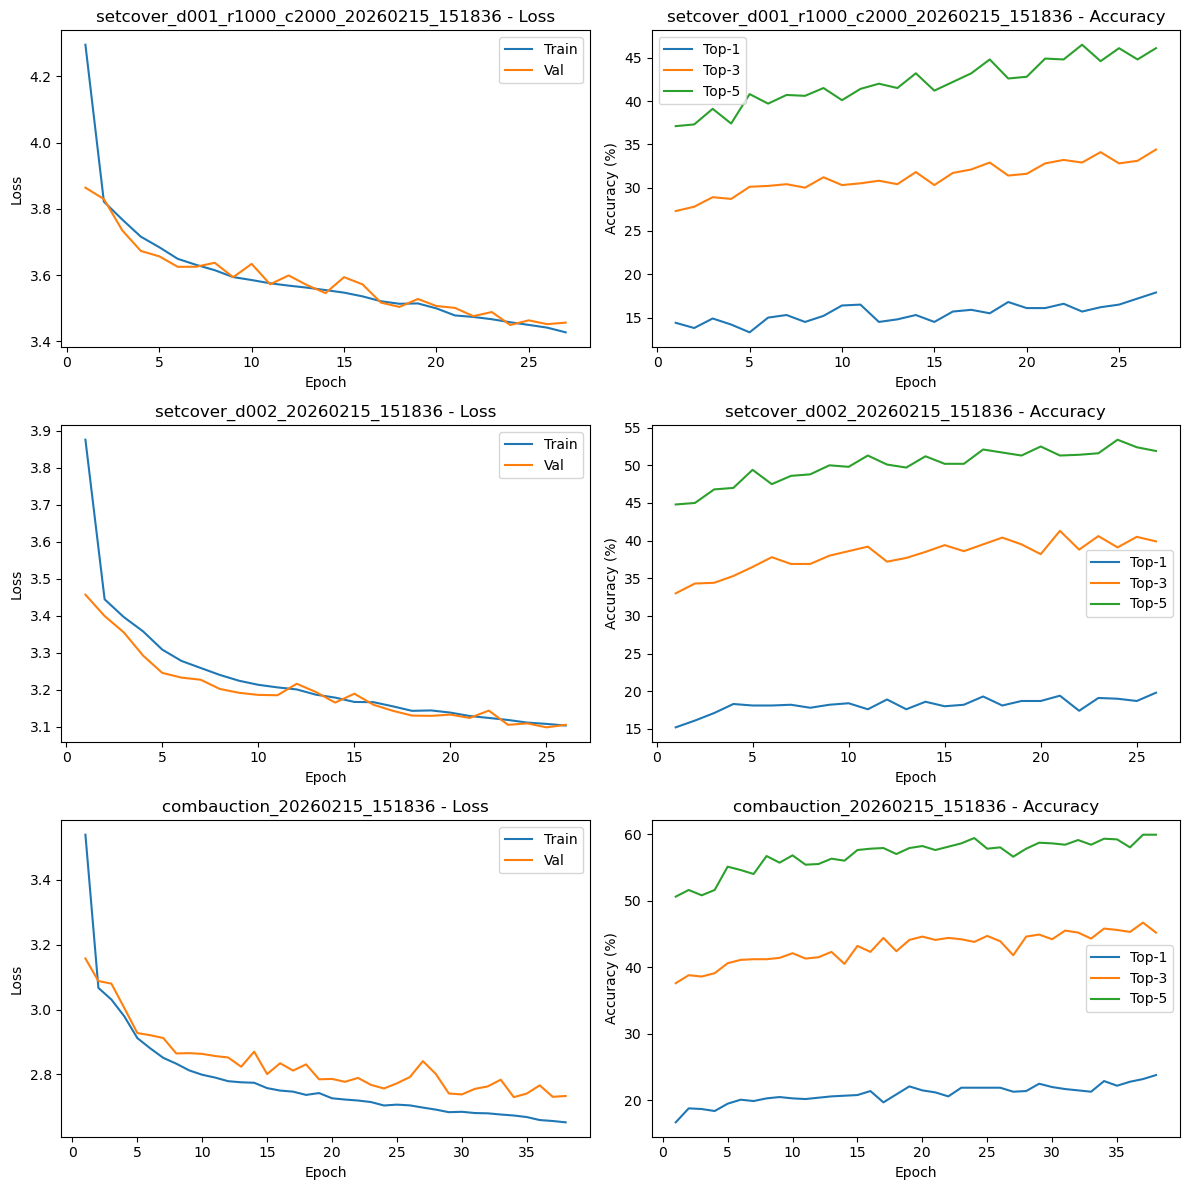

In [4]:
n = len(available)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n), squeeze=False)

for row, (name, paths) in enumerate(available.items()):
    ckpt = torch.load(paths['ckpt'], map_location='cpu', weights_only=False)
    h = ckpt.get('history', {})
    if not h or 'train_loss' not in h:
        axes[row, 0].text(0.5, 0.5, 'No history', ha='center', va='center')
        axes[row, 1].text(0.5, 0.5, 'No history', ha='center', va='center')
        continue

    epochs = range(1, len(h['train_loss']) + 1)

    ax = axes[row, 0]
    ax.plot(epochs, h['train_loss'], label='Train')
    ax.plot(epochs, h['val_loss'], label='Val')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{name} - Loss')
    ax.legend()

    ax = axes[row, 1]
    for k in [1, 3, 5]:
        key = f'val_top{k}'
        if key in h:
            ax.plot(epochs, [v * 100 for v in h[key]], label=f'Top-{k}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{name} - Accuracy')
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Sparsity Statistics

In [5]:
sparsity_stats = {}

for name, paths in available.items():
    with open(paths['data'], 'rb') as f:
        samples = pickle.load(f)

    n_vars_list = [s['variable_features'].shape[0] for s in samples]
    n_cons_list = [s['constraint_features'].shape[0] for s in samples]
    n_edges_list = [s['edge_indices'].shape[1] for s in samples]
    densities = [ne / (nv * nc) if nv * nc > 0 else 0
                 for ne, nv, nc in zip(n_edges_list, n_vars_list, n_cons_list)]
    edges_per_con = []
    edges_per_var = []
    for s in samples:
        ei = s['edge_indices']
        _, con_counts = np.unique(ei[0], return_counts=True)
        _, var_counts = np.unique(ei[1], return_counts=True)
        edges_per_con.extend(con_counts.tolist())
        edges_per_var.extend(var_counts.tolist())

    stats = {
        'samples': len(samples),
        'var_dim': samples[0]['variable_features'].shape[1],
        'con_dim': samples[0]['constraint_features'].shape[1],
        'avg_vars': np.mean(n_vars_list),
        'avg_cons': np.mean(n_cons_list),
        'avg_edges': np.mean(n_edges_list),
        'avg_density': np.mean(densities),
        'min_density': np.min(densities),
        'max_density': np.max(densities),
        'avg_edges_per_con': np.mean(edges_per_con),
        'avg_edges_per_var': np.mean(edges_per_var),
        'max_edges_per_con': np.max(edges_per_con),
        'max_edges_per_var': np.max(edges_per_var),
    }
    sparsity_stats[name] = stats

    print(f'\n--- {name} ---')
    for k, v in stats.items():
        if isinstance(v, float):
            print(f'  {k}: {v:.4f}')
        else:
            print(f'  {k}: {v}')


--- setcover_d001_r1000_c2000_20260215_151836 ---
  samples: 10000
  var_dim: 19
  con_dim: 5
  avg_vars: 1367.4216
  avg_cons: 1019.6154
  avg_edges: 21405.7444
  avg_density: 0.0162
  min_density: 0.0101
  max_density: 0.0382
  avg_edges_per_con: 20.9939
  avg_edges_per_var: 15.6541
  max_edges_per_con: 1194
  max_edges_per_var: 65

--- setcover_d002_20260215_151836 ---
  samples: 10000
  var_dim: 19
  con_dim: 5
  avg_vars: 446.8240
  avg_cons: 516.9088
  avg_edges: 10454.0293
  avg_density: 0.0452
  min_density: 0.0290
  max_density: 0.1386
  avg_edges_per_con: 20.2241
  avg_edges_per_var: 23.3963
  max_edges_per_con: 789
  max_edges_per_var: 121

--- combauction_20260215_151836 ---
  samples: 10000
  var_dim: 19
  con_dim: 5
  avg_vars: 391.7334
  avg_cons: 213.7186
  avg_edges: 6114.2651
  avg_density: 0.0732
  min_density: 0.0374
  max_density: 0.2880
  avg_edges_per_con: 28.6090
  avg_edges_per_var: 15.6082
  max_edges_per_con: 428
  max_edges_per_var: 120


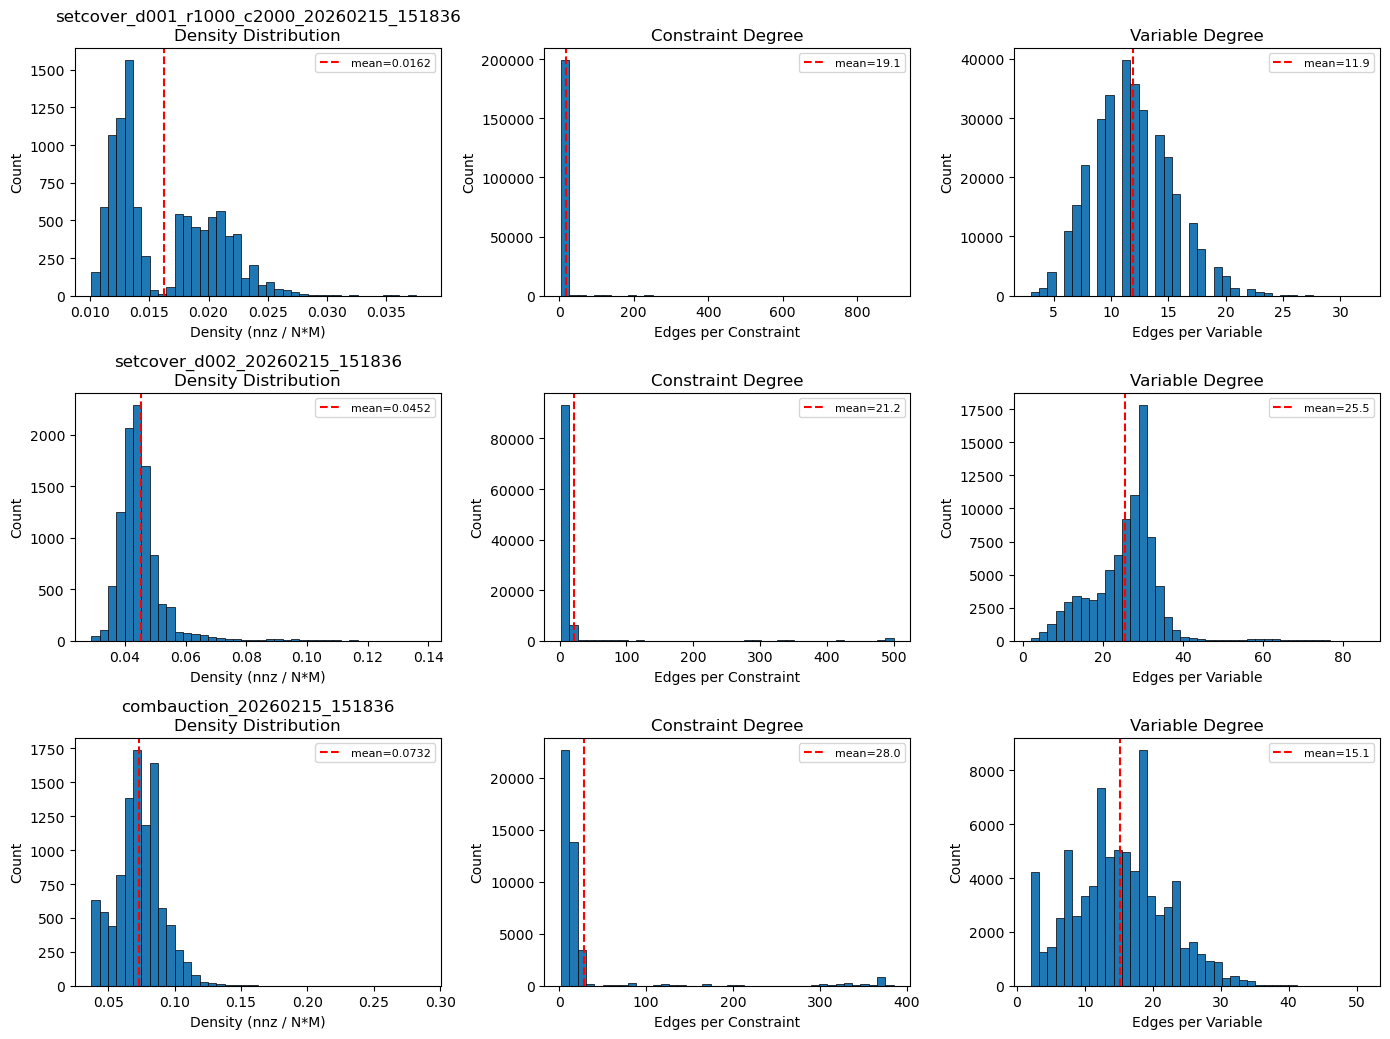

In [6]:
# Sparsity distribution plots
n = len(available)
fig, axes = plt.subplots(n, 3, figsize=(14, 3.5 * n), squeeze=False)

for row, (name, paths) in enumerate(available.items()):
    with open(paths['data'], 'rb') as f:
        samples = pickle.load(f)

    n_edges_list = [s['edge_indices'].shape[1] for s in samples]
    n_vars_list = [s['variable_features'].shape[0] for s in samples]
    n_cons_list = [s['constraint_features'].shape[0] for s in samples]
    densities = [ne / (nv * nc) if nv * nc > 0 else 0
                 for ne, nv, nc in zip(n_edges_list, n_vars_list, n_cons_list)]

    # Collect degree distributions from a subset
    subset = samples[:200]
    epc, epv = [], []
    for s in subset:
        ei = s['edge_indices']
        _, cc = np.unique(ei[0], return_counts=True)
        _, vc = np.unique(ei[1], return_counts=True)
        epc.extend(cc.tolist())
        epv.extend(vc.tolist())

    ax = axes[row, 0]
    ax.hist(densities, bins=40, edgecolor='black', linewidth=0.5)
    ax.axvline(np.mean(densities), color='red', linestyle='--', label=f'mean={np.mean(densities):.4f}')
    ax.set_xlabel('Density (nnz / N*M)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}\nDensity Distribution')
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.hist(epc, bins=40, edgecolor='black', linewidth=0.5)
    ax.axvline(np.mean(epc), color='red', linestyle='--', label=f'mean={np.mean(epc):.1f}')
    ax.set_xlabel('Edges per Constraint')
    ax.set_ylabel('Count')
    ax.set_title('Constraint Degree')
    ax.legend(fontsize=8)

    ax = axes[row, 2]
    ax.hist(epv, bins=40, edgecolor='black', linewidth=0.5)
    ax.axvline(np.mean(epv), color='red', linestyle='--', label=f'mean={np.mean(epv):.1f}')
    ax.set_xlabel('Edges per Variable')
    ax.set_ylabel('Count')
    ax.set_title('Variable Degree')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Inference on Real Samples


setcover_d001_r1000_c2000_20260215_151836
 Idx  Cands  Expert    Pred  Expert Rank  Top-1  Top-3
-------------------------------------------------------
   0    302     417      79            2      0      1
   1    285     944      79           16      0      0
   2    301     136     136            0      1      1
   3    305     944      82            3      0      0
   4    298     757      82            3      0      0


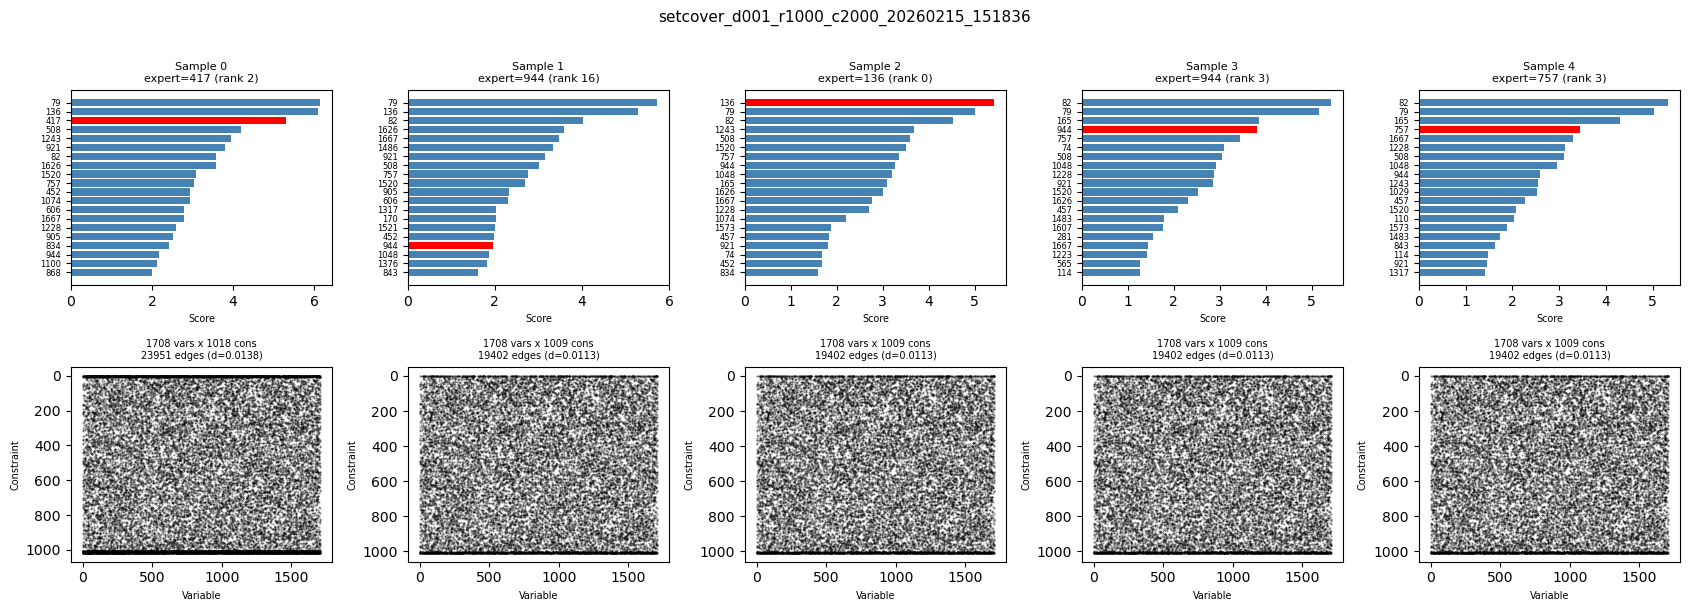


setcover_d002_20260215_151836
 Idx  Cands  Expert    Pred  Expert Rank  Top-1  Top-3
-------------------------------------------------------
   0    161     115     115            0      1      1
   1    158     182     182            0      1      1
   2    134     224     182            2      0      1
   3    121     130     105           18      0      0
   4    132      78     182            2      0      1


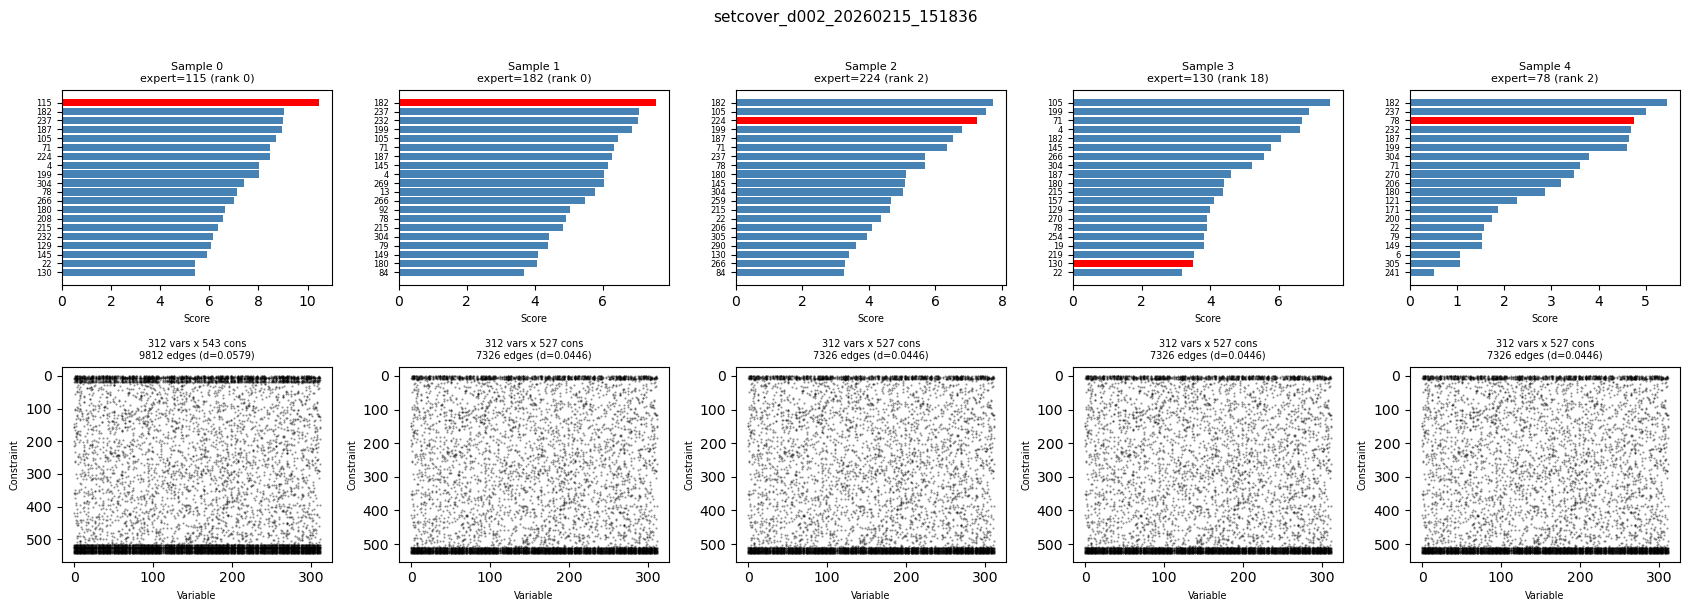


combauction_20260215_151836
 Idx  Cands  Expert    Pred  Expert Rank  Top-1  Top-3
-------------------------------------------------------
   0    112     245     272          111      0      0
   1     82     104     210           79      0      0
   2     67      94     278           66      0      0
   3     50     257     278           48      0      0
   4     52      23     189           23      0      0


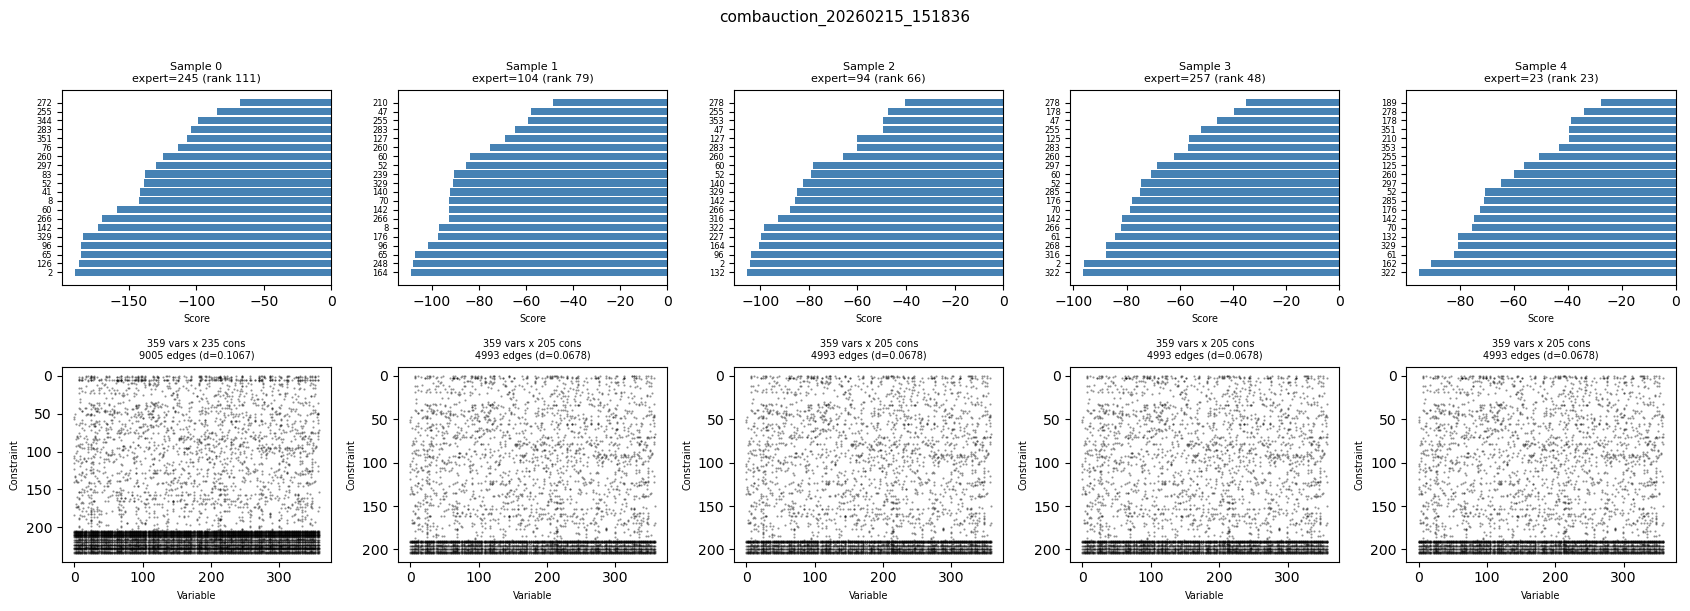

In [7]:
n_demo = 5

for name, paths in available.items():
    print(f'\n{"=" * 70}')
    print(f'{name}')
    print(f'{"=" * 70}')

    ckpt = torch.load(paths['ckpt'], map_location='cpu', weights_only=False)
    model = BipartiteGNN(var_dim=19, con_dim=5, emb_dim=64)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    with open(paths['data'], 'rb') as f:
        samples = pickle.load(f)

    print(f'{"Idx":>4}  {"Cands":>5}  {"Expert":>6}  {"Pred":>6}  '
          f'{"Expert Rank":>11}  {"Top-1":>5}  {"Top-3":>5}')
    print('-' * 55)

    fig, axes = plt.subplots(2, n_demo, figsize=(3.4 * n_demo, 6),
                             gridspec_kw={'height_ratios': [1, 1]})

    for i in range(n_demo):
        s = samples[i]
        vf = torch.tensor(s['variable_features'], dtype=torch.float32)
        cf = torch.tensor(s['constraint_features'], dtype=torch.float32)
        ei = torch.tensor(s['edge_indices'], dtype=torch.long)
        ev = torch.tensor(s['edge_values'], dtype=torch.float32)
        mask = torch.tensor(s['action_mask'], dtype=torch.bool)
        expert = s['expert_action']

        with torch.no_grad():
            scores = model(vf, cf, ei, ev, mask)

        valid_idx = torch.where(mask)[0]
        valid_scores = scores[mask]
        sorted_order = valid_scores.argsort(descending=True)
        sorted_idx = valid_idx[sorted_order]

        pred = sorted_idx[0].item()
        expert_rank = (sorted_idx == expert).nonzero(as_tuple=True)[0]
        expert_rank = expert_rank[0].item() if len(expert_rank) > 0 else -1
        top1 = int(expert_rank == 0)
        top3 = int(0 <= expert_rank < 3)

        print(f'{i:4d}  {len(valid_idx):5d}  {expert:6d}  {pred:6d}  '
              f'{expert_rank:11d}  {top1:5d}  {top3:5d}')

        # Top row: score bar chart
        ax = axes[0, i]
        top_k = min(20, len(sorted_idx))
        bar_idx = sorted_idx[:top_k].numpy()
        bar_scores = valid_scores[sorted_order[:top_k]].numpy()
        colors = ['red' if idx == expert else 'steelblue' for idx in bar_idx]
        ax.barh(range(top_k), bar_scores, color=colors)
        ax.set_yticks(range(top_k))
        ax.set_yticklabels([str(v) for v in bar_idx], fontsize=6)
        ax.invert_yaxis()
        ax.set_xlabel('Score', fontsize=7)
        ax.set_title(f'Sample {i}\nexpert={expert} (rank {expert_rank})', fontsize=8)

        # Bottom row: sparsity pattern
        ax = axes[1, i]
        ei_np = s['edge_indices']
        ax.scatter(ei_np[1], ei_np[0], s=0.3, alpha=0.4, c='black')
        ax.set_xlabel('Variable', fontsize=7)
        ax.set_ylabel('Constraint', fontsize=7)
        n_v = s['variable_features'].shape[0]
        n_c = s['constraint_features'].shape[0]
        density = ei_np.shape[1] / (n_v * n_c)
        ax.set_title(f'{n_v} vars x {n_c} cons\n{ei_np.shape[1]} edges (d={density:.4f})', fontsize=7)
        ax.invert_yaxis()

    fig.suptitle(name, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

## 5. Sparsity Summary Table

In [8]:
header = f'{"Dataset":<45} {"Samples":>7} {"Vars":>7} {"Cons":>7} {"Edges":>8} {"Density":>8} {"MaxDeg(C)":>10} {"MaxDeg(V)":>10}'
print(header)
print('-' * len(header))
for name, st in sparsity_stats.items():
    print(f'{name:<45} {st["samples"]:>7} {st["avg_vars"]:>7.0f} {st["avg_cons"]:>7.0f} '
          f'{st["avg_edges"]:>8.0f} {st["avg_density"]:>8.4f} '
          f'{st["max_edges_per_con"]:>10} {st["max_edges_per_var"]:>10}')

Dataset                                       Samples    Vars    Cons    Edges  Density  MaxDeg(C)  MaxDeg(V)
-------------------------------------------------------------------------------------------------------------
setcover_d001_r1000_c2000_20260215_151836       10000    1367    1020    21406   0.0162       1194         65
setcover_d002_20260215_151836                   10000     447     517    10454   0.0452        789        121
combauction_20260215_151836                     10000     392     214     6114   0.0732        428        120
